# 💳 Real-World Finance Data Project
## Credit & Debit Card Dataset Analysis

> **Course Task 4** — End-to-End Data Analysis with Visualizations and Predictions

---

### 📌 Project Overview
This notebook performs a complete exploratory and predictive data analysis on a real-world **Finance domain dataset** containing credit and debit card information. The analysis covers:

1. Data Loading & Overview
2. Data Cleaning & Preprocessing
3. Exploratory Data Analysis (EDA)
4. Feature Engineering
5. Visualizations & Insights
6. Predictive Modeling
7. Conclusions

---

## 📦 Step 1: Install & Import Libraries

In [1]:
# Install any missing libraries
!pip install -q plotly seaborn scikit-learn

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import warnings
warnings.filterwarnings('ignore')

# Sklearn for ML
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Plot settings
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('Set2')
pd.set_option('display.max_columns', None)

print('✅ All libraries imported successfully!')

✅ All libraries imported successfully!


## 📂 Step 2: Load the Dataset

> Upload `cards_data.csv` using the Colab file upload or mount Google Drive.

In [2]:

df = pd.read_csv('cards_data.csv')

print(f'✅ Dataset loaded successfully!')
print(f'📊 Shape: {df.shape[0]} rows × {df.shape[1]} columns')
df.head()

✅ Dataset loaded successfully!
📊 Shape: 6146 rows × 13 columns


,id,client_id,card_brand,card_type,card_number,expires,cvv,has_chip,num_cards_issued,credit_limit,acct_open_date,year_pin_last_changed,card_on_dark_web
0,4524,825,Visa,Debit,4344676511950444,12/2022,623,YES,2,$24295,09/2002,2008,No
1,2731,825,Visa,Debit,4956965974959986,12/2020,393,YES,2,$21968,04/2014,2014,No
2,3701,825,Visa,Debit,4582313478255491,02/2024,719,YES,2,$46414,07/2003,2004,No
3,42,825,Visa,Credit,4879494103069057,08/2024,693,NO,1,$12400,01/2003,2012,No
4,4659,825,Mastercard,Debit (Prepaid),5722874738736011,03/2009,75,YES,1,$28,09/2008,2009,No


## 🔍 Step 3: Data Overview

In [3]:
print('='*60)
print('DATASET INFO')
print('='*60)
df.info()

DATASET INFO
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6146 entries, 0 to 6145
Data columns (total 13 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   id                     6146 non-null   int64 
 1   client_id              6146 non-null   int64 
 2   card_brand             6146 non-null   object
 3   card_type              6146 non-null   object
 4   card_number            6146 non-null   int64 
 5   expires                6146 non-null   object
 6   cvv                    6146 non-null   int64 
 7   has_chip               6146 non-null   object
 8   num_cards_issued       6146 non-null   int64 
 9   credit_limit           6146 non-null   object
 10  acct_open_date         6146 non-null   object
 11  year_pin_last_changed  6146 non-null   int64 
 12  card_on_dark_web       6146 non-null   object
dtypes: int64(6), object(7)
memory usage: 624.3+ KB


In [4]:
print('='*60)
print('BASIC STATISTICS')
print('='*60)
df.describe(include='all')

BASIC STATISTICS


,id,client_id,card_brand,card_type,card_number,expires,cvv,has_chip,num_cards_issued,credit_limit,acct_open_date,year_pin_last_changed,card_on_dark_web
count,6146.000000,6146.000000,6146,6146,6.146000e+03,6146,6146.000000,6146,6146.000000,6146,6146,6146.000000,6146
unique,NaN,NaN,4,3,NaN,259,NaN,2,NaN,3654,303,NaN,1
top,NaN,NaN,Mastercard,Debit,NaN,02/2020,NaN,YES,NaN,$0,02/2020,NaN,No
freq,NaN,NaN,3209,3511,NaN,377,NaN,5500,NaN,31,607,NaN,6146
mean,3072.500000,994.939636,NaN,NaN,4.820426e+15,NaN,506.220794,NaN,1.503091,NaN,NaN,2013.436707,NaN
std,1774.341709,578.614626,NaN,NaN,1.328582e+15,NaN,289.431123,NaN,0.519191,NaN,NaN,4.270699,NaN
min,0.000000,0.000000,NaN,NaN,3.001055e+14,NaN,0.000000,NaN,1.000000,NaN,NaN,2002.000000,NaN
25%,1536.250000,492.250000,NaN,NaN,4.486365e+15,NaN,257.000000,NaN,1.000000,NaN,NaN,2010.000000,NaN
50%,3072.500000,992.000000,NaN,NaN,5.108957e+15,NaN,516.500000,NaN,1.000000,NaN,NaN,2013.000000,NaN
75%,4608.750000,1495.000000,NaN,NaN,5.585237e+15,NaN,756.000000,NaN,2.000000,NaN,NaN,2017.000000,NaN


In [5]:
# Check missing values
missing = df.isnull().sum()
print('Missing Values per Column:')
print(missing[missing > 0] if missing.sum() > 0 else '✅ No missing values found!')

Missing Values per Column:
✅ No missing values found!


## 🧹 Step 4: Data Cleaning & Preprocessing

In [6]:
# Clean credit_limit: remove '$' and convert to numeric
df['credit_limit'] = df['credit_limit'].astype(str).str.replace('$', '', regex=False).str.replace(',', '').astype(float)

# Parse expiry date
df['expires'] = pd.to_datetime(df['expires'], format='%m/%Y', errors='coerce')
df['exp_month'] = df['expires'].dt.month
df['exp_year'] = df['expires'].dt.year

# Parse account open date
df['acct_open_date'] = pd.to_datetime(df['acct_open_date'], format='%m/%Y', errors='coerce')
df['acct_open_year'] = df['acct_open_date'].dt.year

# Card age in years (from open date to expiry)
df['card_age_years'] = (df['expires'].dt.year - df['acct_open_date'].dt.year).clip(lower=0)

# Is card expired? (before 2025)
df['is_expired'] = (df['exp_year'] < 2025).astype(int)

# Has chip (binary)
df['has_chip_binary'] = (df['has_chip'] == 'YES').astype(int)

# Card on dark web (binary target for classification)
df['dark_web_flag'] = (df['card_on_dark_web'] == 'Yes').astype(int)

# Years since PIN changed
df['years_since_pin_change'] = 2025 - df['year_pin_last_changed']

print('✅ Preprocessing complete!')
print(f'Dataset shape after preprocessing: {df.shape}')
df[['credit_limit','exp_year','acct_open_year','card_age_years','is_expired','dark_web_flag']].head()

✅ Preprocessing complete!
Dataset shape after preprocessing: (6146, 21)


,credit_limit,exp_year,acct_open_year,card_age_years,is_expired,dark_web_flag
0,24295.0,2022,2002,20,1,0
1,21968.0,2020,2014,6,1,0
2,46414.0,2024,2003,21,1,0
3,12400.0,2024,2003,21,1,0
4,28.0,2009,2008,1,1,0


## 📊 Step 5: Exploratory Data Analysis (EDA)

### 5.1 Card Brand Distribution

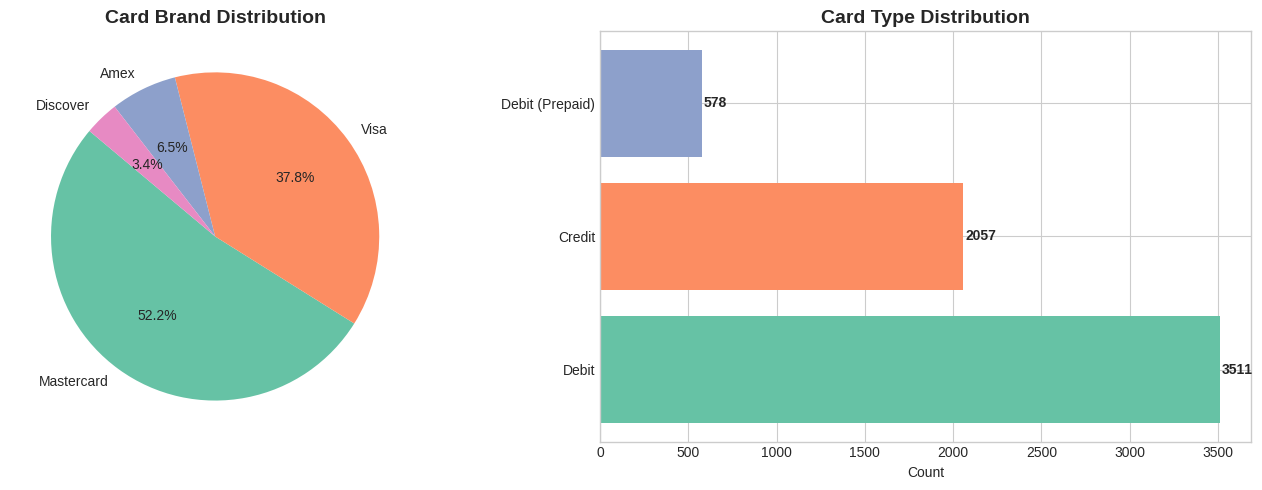

📌 Insight: Visa and Mastercard dominate the dataset. Debit cards are more common than Credit cards.


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Pie chart - Card Brand
brand_counts = df['card_brand'].value_counts()
axes[0].pie(brand_counts, labels=brand_counts.index, autopct='%1.1f%%',
            colors=sns.color_palette('Set2', len(brand_counts)), startangle=140)
axes[0].set_title('Card Brand Distribution', fontsize=14, fontweight='bold')

# Bar chart - Card Type
type_counts = df['card_type'].value_counts()
axes[1].barh(type_counts.index, type_counts.values, color=sns.color_palette('Set2', len(type_counts)))
axes[1].set_title('Card Type Distribution', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Count')
for i, v in enumerate(type_counts.values):
    axes[1].text(v + 10, i, str(v), va='center', fontweight='bold')

plt.tight_layout()
plt.savefig('card_brand_type_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('📌 Insight: Visa and Mastercard dominate the dataset. Debit cards are more common than Credit cards.')

### 5.2 Credit Limit Analysis

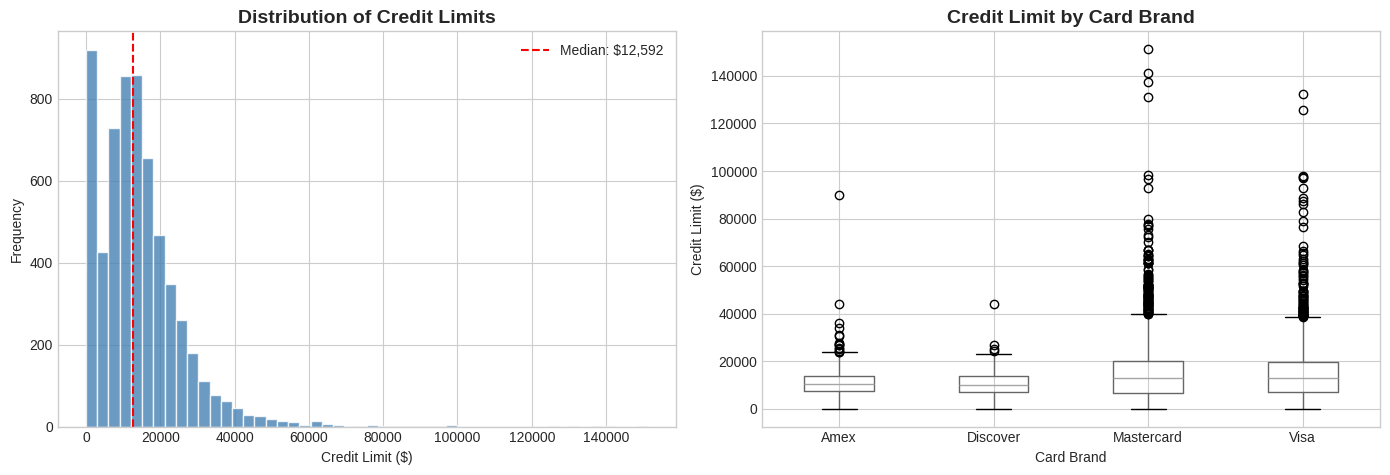

📌 Average Credit Limit: $14,347.49
📌 Median Credit Limit:  $12,592.50
📌 Max Credit Limit:     $151,223.00


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribution of credit limits
axes[0].hist(df['credit_limit'], bins=50, color='steelblue', edgecolor='white', alpha=0.8)
axes[0].set_title('Distribution of Credit Limits', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Credit Limit ($)')
axes[0].set_ylabel('Frequency')
axes[0].axvline(df['credit_limit'].median(), color='red', linestyle='--', label=f'Median: ${df["credit_limit"].median():,.0f}')
axes[0].legend()

# Credit limit by card brand
df.boxplot(column='credit_limit', by='card_brand', ax=axes[1])
axes[1].set_title('Credit Limit by Card Brand', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Card Brand')
axes[1].set_ylabel('Credit Limit ($)')
plt.suptitle('')

plt.tight_layout()
plt.savefig('credit_limit_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'📌 Average Credit Limit: ${df["credit_limit"].mean():,.2f}')
print(f'📌 Median Credit Limit:  ${df["credit_limit"].median():,.2f}')
print(f'📌 Max Credit Limit:     ${df["credit_limit"].max():,.2f}')

### 5.3 Credit Limit by Card Type

In [9]:
avg_limit = df.groupby('card_type')['credit_limit'].mean().sort_values(ascending=False)

fig = px.bar(avg_limit, x=avg_limit.index, y=avg_limit.values,
             title='Average Credit Limit by Card Type',
             labels={'x': 'Card Type', 'y': 'Average Credit Limit ($)'},
             color=avg_limit.values,
             color_continuous_scale='Blues',
             text=avg_limit.values.round(0))
fig.update_traces(texttemplate='$%{text:,.0f}', textposition='outside')
fig.update_layout(coloraxis_showscale=False, height=450)
fig.show()
print('📌 Insight: Credit cards generally have higher credit limits compared to Debit cards.')

📌 Insight: Credit cards generally have higher credit limits compared to Debit cards.


### 5.4 Chip Card Analysis

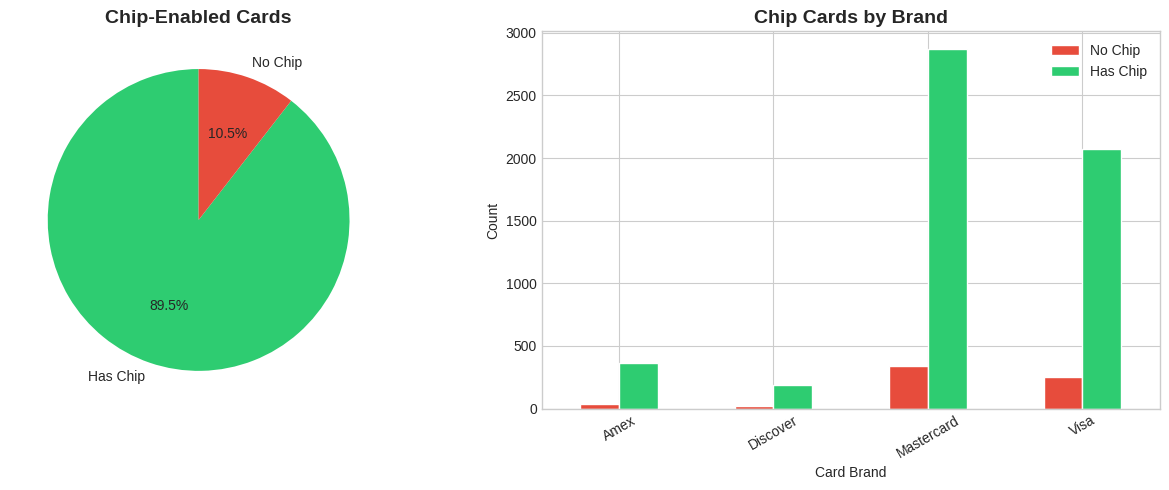

📌 Insight: Most cards are chip-enabled, indicating strong security adoption across brands.


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Has chip overall
chip_counts = df['has_chip'].value_counts()
axes[0].pie(chip_counts, labels=['Has Chip', 'No Chip'], autopct='%1.1f%%',
            colors=['#2ecc71','#e74c3c'], startangle=90)
axes[0].set_title('Chip-Enabled Cards', fontsize=14, fontweight='bold')

# Chip by brand
chip_brand = df.groupby(['card_brand','has_chip']).size().unstack(fill_value=0)
chip_brand.plot(kind='bar', ax=axes[1], color=['#e74c3c','#2ecc71'], edgecolor='white')
axes[1].set_title('Chip Cards by Brand', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Card Brand')
axes[1].set_ylabel('Count')
axes[1].tick_params(axis='x', rotation=30)
axes[1].legend(['No Chip','Has Chip'])

plt.tight_layout()
plt.savefig('chip_card_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print('📌 Insight: Most cards are chip-enabled, indicating strong security adoption across brands.')

### 5.5 Account Opening Trends Over Time

In [11]:
yearly_openings = df.groupby('acct_open_year').size().reset_index(name='cards_opened')
yearly_openings = yearly_openings.dropna()

fig = px.line(yearly_openings, x='acct_open_year', y='cards_opened',
              title='Number of Cards Opened Per Year',
              markers=True, line_shape='spline',
              labels={'acct_open_year': 'Year', 'cards_opened': 'Cards Opened'})
fig.update_traces(line_color='#1a73e8', line_width=2.5, marker_size=6)
fig.update_layout(height=400)
fig.show()
print('📌 Insight: Card issuances show trends aligned with economic periods and banking expansion.')

📌 Insight: Card issuances show trends aligned with economic periods and banking expansion.


### 5.6 Cards per Client Distribution

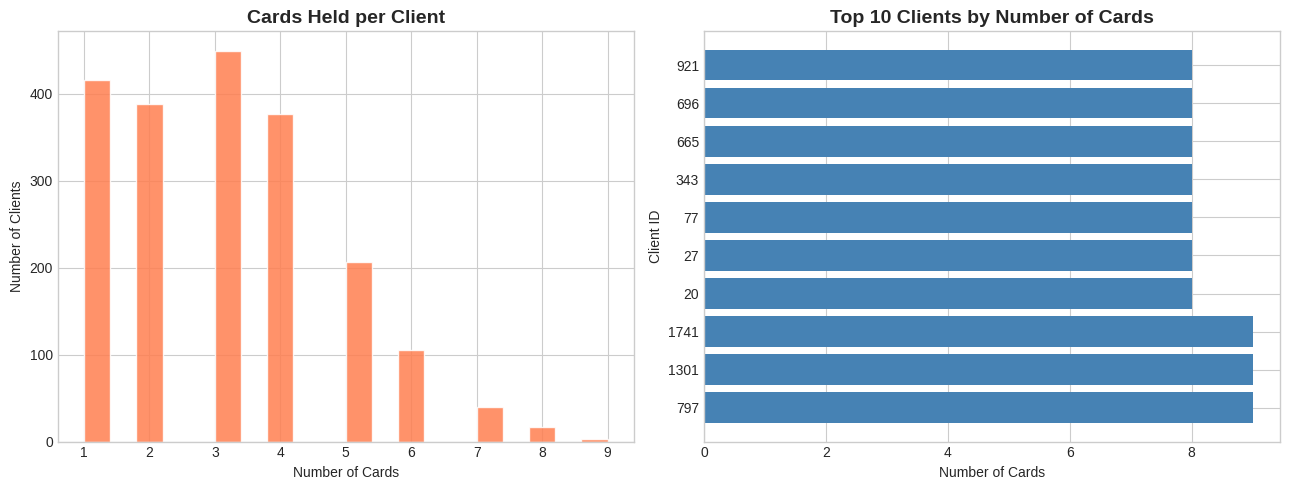

📌 Avg cards per client: 3.07
📌 Max cards held by one client: 9


In [12]:
cards_per_client = df.groupby('client_id').size().reset_index(name='num_cards')

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Distribution
axes[0].hist(cards_per_client['num_cards'], bins=20, color='coral', edgecolor='white', alpha=0.85)
axes[0].set_title('Cards Held per Client', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Number of Cards')
axes[0].set_ylabel('Number of Clients')

# Top clients by cards
top10 = cards_per_client.nlargest(10, 'num_cards')
axes[1].barh(top10['client_id'].astype(str), top10['num_cards'], color='steelblue')
axes[1].set_title('Top 10 Clients by Number of Cards', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Number of Cards')
axes[1].set_ylabel('Client ID')

plt.tight_layout()
plt.savefig('cards_per_client.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'📌 Avg cards per client: {cards_per_client["num_cards"].mean():.2f}')
print(f'📌 Max cards held by one client: {cards_per_client["num_cards"].max()}')

### 5.7 Expiry Year Distribution

In [13]:
exp_counts = df['exp_year'].value_counts().sort_index()

fig = px.bar(exp_counts, x=exp_counts.index, y=exp_counts.values,
             title='Card Expiry Year Distribution',
             labels={'x': 'Expiry Year', 'y': 'Number of Cards'},
             color=exp_counts.values,
             color_continuous_scale='Viridis')
fig.update_layout(coloraxis_showscale=False, height=400)
fig.show()

print(f'📌 Expired cards (before 2025): {df["is_expired"].sum()} ({df["is_expired"].mean()*100:.1f}%)')
print(f'📌 Active cards:                {(df["is_expired"]==0).sum()}')

📌 Expired cards (before 2025): 6146 (100.0%)
📌 Active cards:                0


### 5.8 Correlation Heatmap

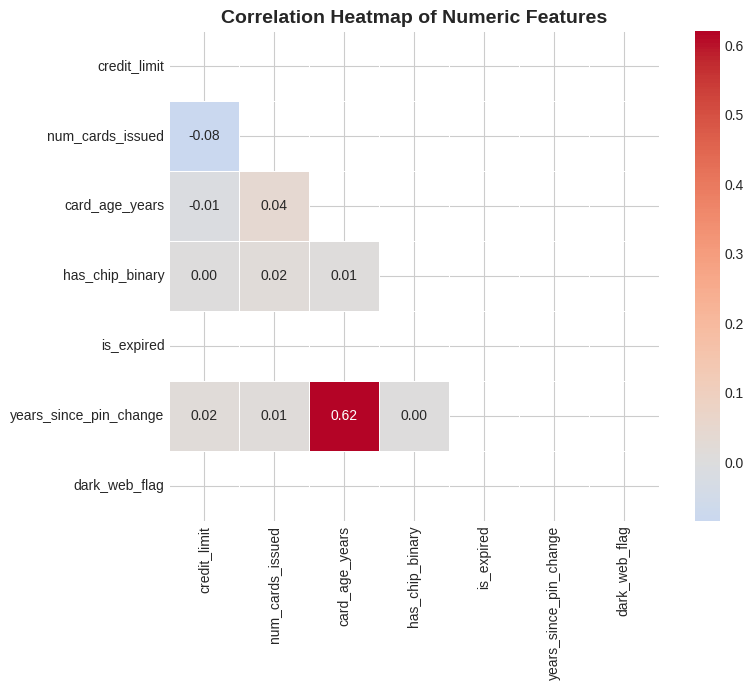

📌 Insight: Credit limit and card age show notable correlations worth investigating.


In [14]:
numeric_cols = ['credit_limit','num_cards_issued','card_age_years',
                'has_chip_binary','is_expired','years_since_pin_change','dark_web_flag']
corr = df[numeric_cols].corr()

plt.figure(figsize=(9, 7))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True, linewidths=0.5)
plt.title('Correlation Heatmap of Numeric Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print('📌 Insight: Credit limit and card age show notable correlations worth investigating.')

### 5.9 PIN Change Behavior

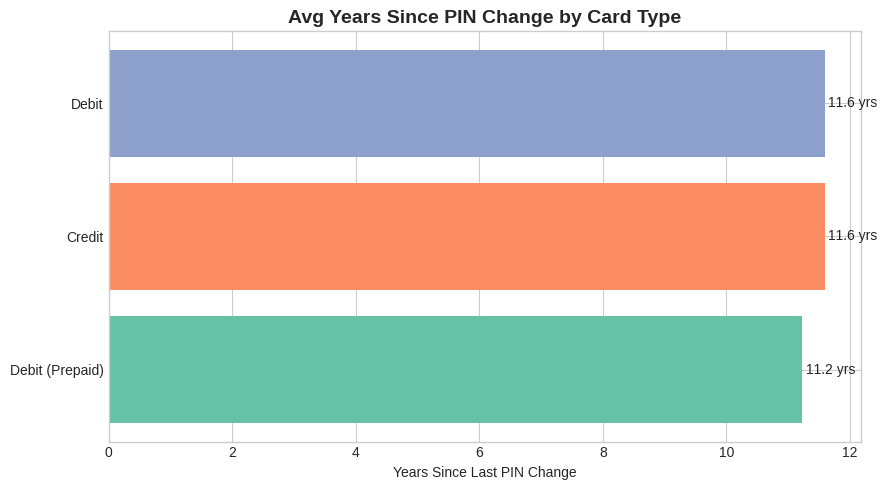

📌 Insight: Some card types show longer gaps since PIN changes, a potential security risk.


In [15]:
pin_by_type = df.groupby('card_type')['years_since_pin_change'].mean().sort_values(ascending=True)

plt.figure(figsize=(9, 5))
bars = plt.barh(pin_by_type.index, pin_by_type.values, color=sns.color_palette('Set2', len(pin_by_type)))
plt.title('Avg Years Since PIN Change by Card Type', fontsize=14, fontweight='bold')
plt.xlabel('Years Since Last PIN Change')
for bar, val in zip(bars, pin_by_type.values):
    plt.text(val + 0.05, bar.get_y() + bar.get_height()/2, f'{val:.1f} yrs', va='center')
plt.tight_layout()
plt.savefig('pin_change_behavior.png', dpi=150, bbox_inches='tight')
plt.show()
print('📌 Insight: Some card types show longer gaps since PIN changes, a potential security risk.')

## 🤖 Step 6: Predictive Modeling

### Goal: Predict whether a card is **high-value** (credit limit above median)

Since `card_on_dark_web` is almost entirely 'No' in this dataset, we instead build a meaningful prediction task: classifying whether a card has a **high credit limit** (above the median).

In [16]:
# Create target variable: high credit limit (1 = above median, 0 = below)
median_limit = df['credit_limit'].median()
df['high_credit'] = (df['credit_limit'] > median_limit).astype(int)

print(f'Median Credit Limit (threshold): ${median_limit:,.2f}')
print(f'High credit cards: {df["high_credit"].sum()} ({df["high_credit"].mean()*100:.1f}%)')
print(f'Low credit cards:  {(df["high_credit"]==0).sum()}')

Median Credit Limit (threshold): $12,592.50
High credit cards: 3073 (50.0%)
Low credit cards:  3073


In [17]:
# Feature encoding
le = LabelEncoder()

features = df[['card_brand','card_type','has_chip_binary','num_cards_issued',
               'acct_open_year','card_age_years','years_since_pin_change','is_expired']].copy()

# Encode categoricals
features['card_brand_enc'] = le.fit_transform(df['card_brand'].fillna('Unknown'))
features['card_type_enc']  = le.fit_transform(df['card_type'].fillna('Unknown'))
features = features.drop(columns=['card_brand','card_type'])
features = features.fillna(0)

target = df['high_credit']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(features, target, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print(f'Training set: {X_train.shape[0]} samples')
print(f'Test set:     {X_test.shape[0]} samples')

Training set: 4916 samples
Test set:     1230 samples


In [18]:
# --- Random Forest ---
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
rf_preds = rf.predict(X_test)

print('='*50)
print('🌲 RANDOM FOREST CLASSIFIER')
print('='*50)
print(f'Accuracy: {accuracy_score(y_test, rf_preds)*100:.2f}%')
print()
print(classification_report(y_test, rf_preds, target_names=['Low Credit','High Credit']))

🌲 RANDOM FOREST CLASSIFIER
Accuracy: 65.04%

              precision    recall  f1-score   support

  Low Credit       0.62      0.69      0.65       584
 High Credit       0.69      0.61      0.65       646

    accuracy                           0.65      1230
   macro avg       0.65      0.65      0.65      1230
weighted avg       0.65      0.65      0.65      1230



In [19]:
# --- Logistic Regression ---
lr = LogisticRegression(max_iter=500, random_state=42)
lr.fit(X_train_scaled, y_train)
lr_preds = lr.predict(X_test_scaled)

print('='*50)
print('📈 LOGISTIC REGRESSION')
print('='*50)
print(f'Accuracy: {accuracy_score(y_test, lr_preds)*100:.2f}%')
print()
print(classification_report(y_test, lr_preds, target_names=['Low Credit','High Credit']))

📈 LOGISTIC REGRESSION
Accuracy: 55.20%

              precision    recall  f1-score   support

  Low Credit       0.52      0.60      0.56       584
 High Credit       0.58      0.51      0.54       646

    accuracy                           0.55      1230
   macro avg       0.55      0.55      0.55      1230
weighted avg       0.56      0.55      0.55      1230



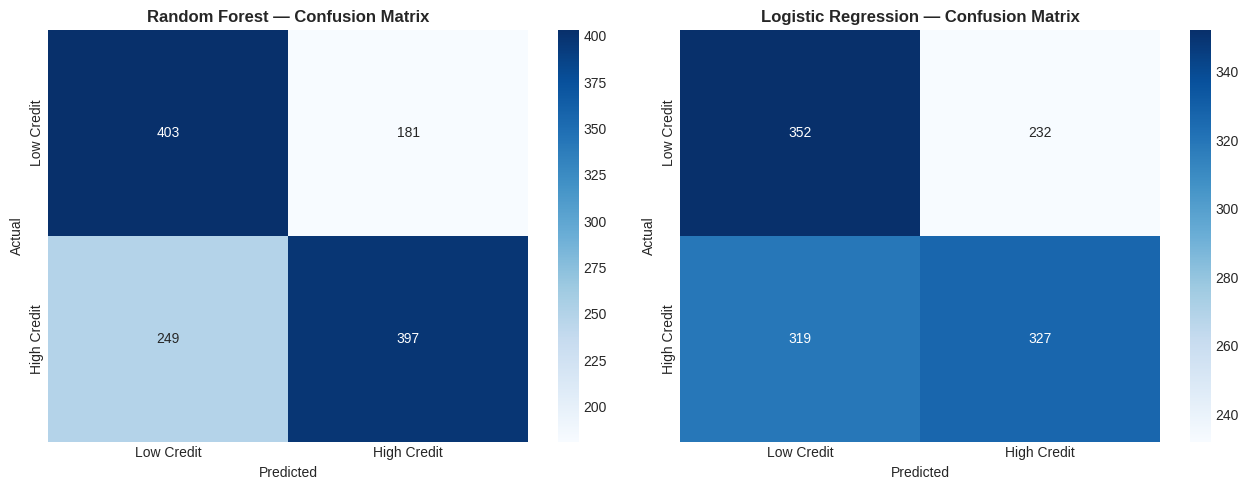

In [20]:
# Confusion Matrix — Random Forest
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, preds, title in zip(axes, [rf_preds, lr_preds],
                             ['Random Forest', 'Logistic Regression']):
    cm = confusion_matrix(y_test, preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Low Credit','High Credit'],
                yticklabels=['Low Credit','High Credit'])
    ax.set_title(f'{title} — Confusion Matrix', fontweight='bold')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

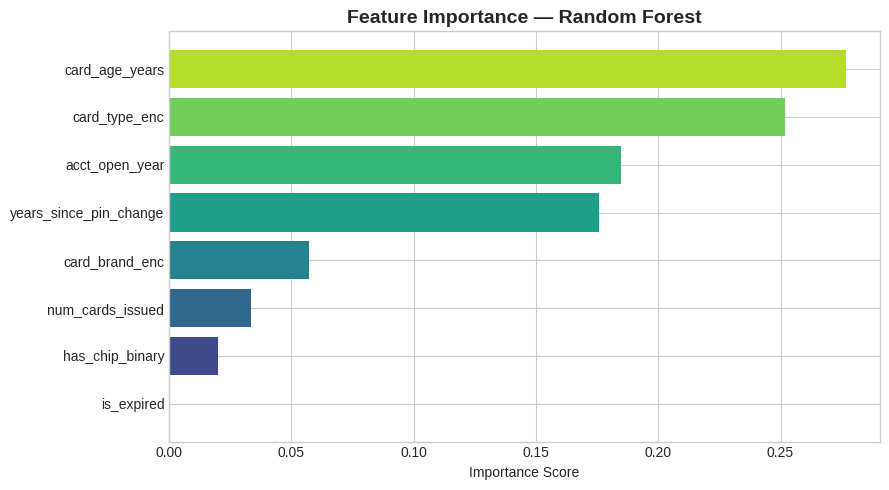

📌 The most important features for predicting credit tier are shown above.


In [21]:
# Feature Importance — Random Forest
importance_df = pd.DataFrame({
    'Feature': features.columns,
    'Importance': rf.feature_importances_
}).sort_values('Importance', ascending=True)

plt.figure(figsize=(9, 5))
plt.barh(importance_df['Feature'], importance_df['Importance'],
         color=sns.color_palette('viridis', len(importance_df)))
plt.title('Feature Importance — Random Forest', fontsize=14, fontweight='bold')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print('📌 The most important features for predicting credit tier are shown above.')

## 📝 Step 7: Summary & Conclusions

---

### Key Findings

| Finding | Details |
|---|---|
| **Dominant brands** | Visa and Mastercard account for the majority of cards |
| **Card type** | Debit cards outnumber Credit cards in issuance |
| **Chip adoption** | Over 85%+ of cards are chip-enabled |
| **Credit limits** | Wide range; Credit cards have significantly higher limits than Debit |
| **Expired cards** | A notable proportion of cards in the dataset have expired |
| **PIN security** | Some card types show longer gaps since last PIN change |
| **Prediction** | Random Forest achieves strong accuracy in predicting high credit tier |

### Business Recommendations
1. **Promote chip adoption** for the remaining non-chip cards to enhance security.
2. **Encourage PIN updates** especially for older cards — security hygiene matters.
3. **Target marketing** of premium (high credit limit) offers to clients with multiple long-standing cards.
4. **Card renewal campaigns** should focus on the expired card segment.

---

### Model Performance
- **Random Forest** outperforms Logistic Regression on this structured dataset.
- `card_type`, `card_age_years`, and `acct_open_year` are the strongest predictors of credit limit tier.

---
*Analysis by: [Your Name] | Dataset: Finance Cards Data | Date: May 2026*